# Seminar 1 — Wi-Fi Performance Prediction with Linear Regression

This notebook implements a multi-variable linear regression model to predict the performance of Wi-Fi deployments using the `dataset_Seminar1.txt` dataset.

**Structure:**
- **Part I** — Data preparation & analysis
- **Part II** — Model implementation & evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from google.colab import drive
#drive.mount('/content/drive')
#%cd /content/drive/MyDrive/

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATASET_PATH = 'dataset_Seminar1.txt'
RANDOM_STATE = 42
TEST_SIZE    = 0.20

---
## Part I — Data Preparation & Analysis

### 1.1 Load the dataset

In [ ]:
# Column names inferred from Wi-Fi simulation context
COLUMN_NAMES = [
    'n_stations',        # Number of stations in the STAs
    'Load',         # Supported data rate (bps)
    'Siex(x)',           # Wi-Fi channel number
    'Size(y)',             # Number of access points
    'Area',       # Total number of active flows
    'cw_size',           # Contention window size
    'channel_width',     # Channel width
    'packet_size',
    'MAX RSSI',     
    'AVG RSSI',      
    'MIN RSSI',    
    'Prob_of_failure', 
    'Throughput',  
    'Average_delay',
    'Total_airtime',
    'Proportional_airtime'
]

df = pd.read_csv(DATASET_PATH, sep=r'\s+', header=None, names=COLUMN_NAMES)

print(f'Shape : {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape : (100000, 16)
Columns: ['n_stations', 'Load', 'Siex(x)', 'Size(y)', 'Area', 'cw_size', 'channel_width', 'packet_size', 'MAX RSSI', 'AVG RSSI', 'MIN RSSI', 'Prob_of_failure', 'Throughput', 'Average_delay', 'Total_airtime', 'Proportional_airtime']


,n_stations,Load,Siex(x),Size(y),Area,cw_size,channel_width,packet_size,MAX RSSI,AVG RSSI,MIN RSSI,Prob_of_failure,Throughput,Average_delay,Total_airtime,Proportional_airtime
0,40.0,60000000.0,22.0,39.0,858.0,63.0,80.0,4000.0,-42.928330,-63.163012,-74.965338,0.415189,7.208644e+06,1.229466e+07,1.084041,0.875490
1,35.0,52500000.0,20.0,33.0,660.0,31.0,40.0,10000.0,-47.815800,-63.298410,-72.847989,0.485311,1.545116e+07,1.275042e+07,1.111263,0.873785
2,16.0,12000000.0,34.0,14.0,476.0,255.0,40.0,4000.0,-46.138494,-60.076333,-70.044800,0.099413,6.743660e+06,2.251690e+06,0.880036,0.849701
3,37.0,18500000.0,35.0,7.0,245.0,31.0,80.0,10000.0,-42.708813,-60.141393,-72.029643,0.493704,1.675025e+07,1.211374e+07,1.126341,0.860103
4,18.0,4500000.0,36.0,35.0,1260.0,127.0,160.0,8000.0,-45.492991,-63.780783,-76.225550,0.011664,4.500000e+06,1.446000e-03,0.276770,0.275687


Here we can see that the values align with expected ranges, for example, MAX RSSI should be bigger than -81 which they all are (they are centered at around -45).

### 1.2 Feature statistics (mean & standard deviation)

In [3]:
stats = df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats.columns = ['Mean', 'Std Dev', 'Min', 'Q1', 'Median', 'Q3', 'Max']
print('=== Feature Statistics ===')
display(stats.style.format('{:.4f}'))

=== Feature Statistics ===


,Mean,Std Dev,Min,Q1,Median,Q3,Max
n_stations,21.4462,11.5544,2.0000,11.0000,21.0000,31.0000,41.0000
Load,21402920.0000,18520420.5347,500000.0000,7250000.0000,16000000.0000,30000000.0000,82000000.0000
Siex(x),20.5629,11.5452,1.0000,11.0000,21.0000,31.0000,40.0000
Size(y),20.4796,11.5406,1.0000,11.0000,20.0000,30.0000,40.0000
Area,421.2704,360.3443,1.0000,120.0000,320.0000,640.0000,1600.0000
cw_size,227.0439,323.3509,3.0000,15.0000,63.0000,255.0000,1023.0000
channel_width,75.1060,53.7043,20.0000,20.0000,80.0000,160.0000,160.0000
packet_size,7997.5800,2825.5325,4000.0000,6000.0000,8000.0000,10000.0000,12000.0000
MAX RSSI,-45.9112,5.4003,-81.4052,-48.1315,-44.1111,-41.8888,-40.8636
AVG RSSI,-57.5774,6.1085,-81.4052,-61.9850,-58.1632,-53.5895,-40.8660


In [13]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

print('\n=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'{dupes} duplicate rows found.')

=== Missing Values ===
No missing values found.

=== Duplicate Rows ===
0 duplicate rows found.


Very IMP, as this avoids us having to do padding or other for pre-processing of dataset.

### 1.3 Data visualisation

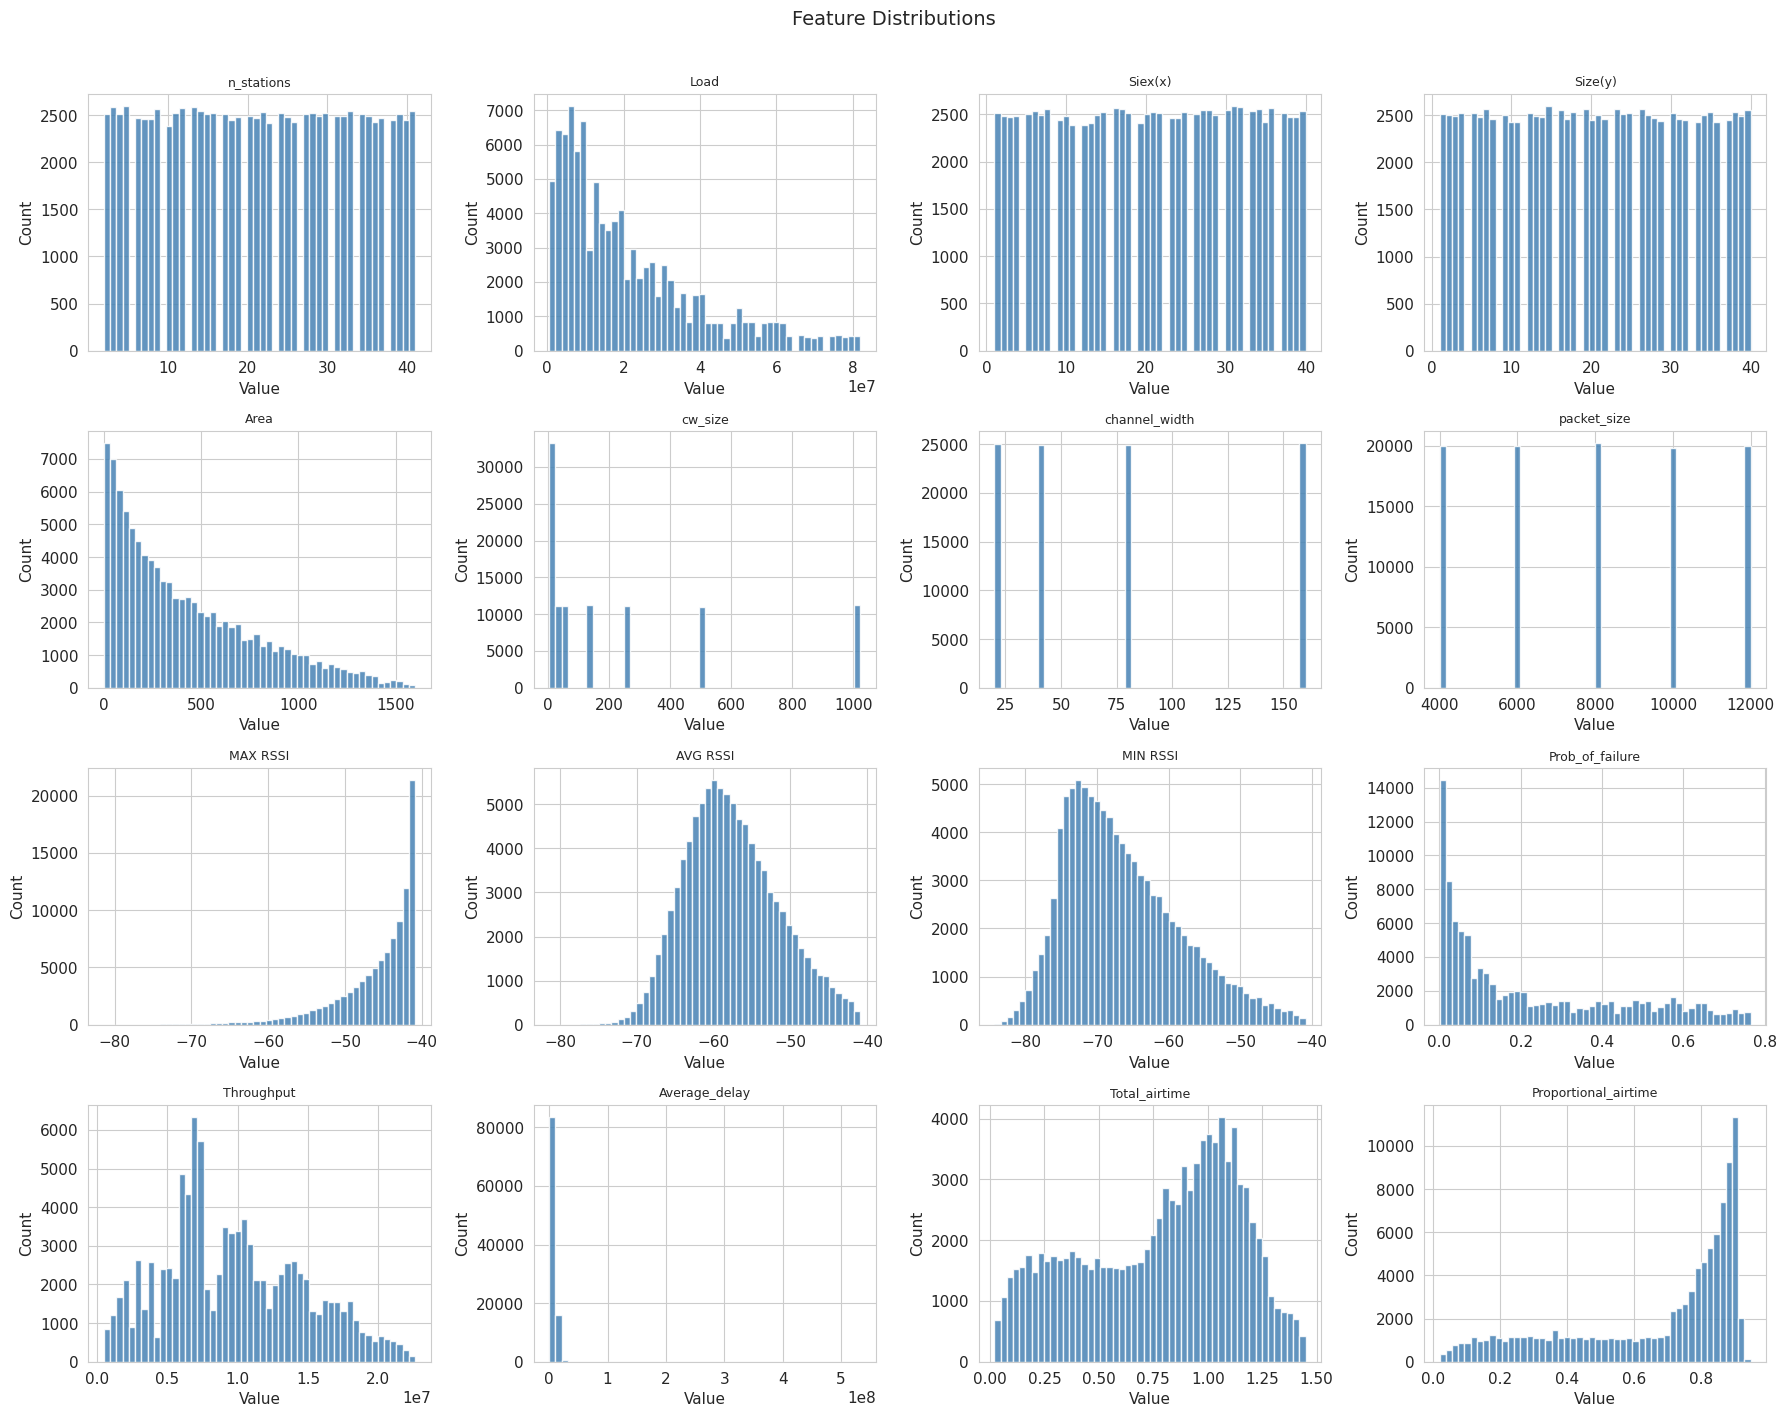

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(COLUMN_NAMES):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Here we can see histogram plots of the different features and labels. We can see different distributions, uniform (number stations, size x/y), normal distributions (avg rsi, min rssi), and exponential distribution (area, load). Some are also very discrete with concrete values like channel width and packet size. 

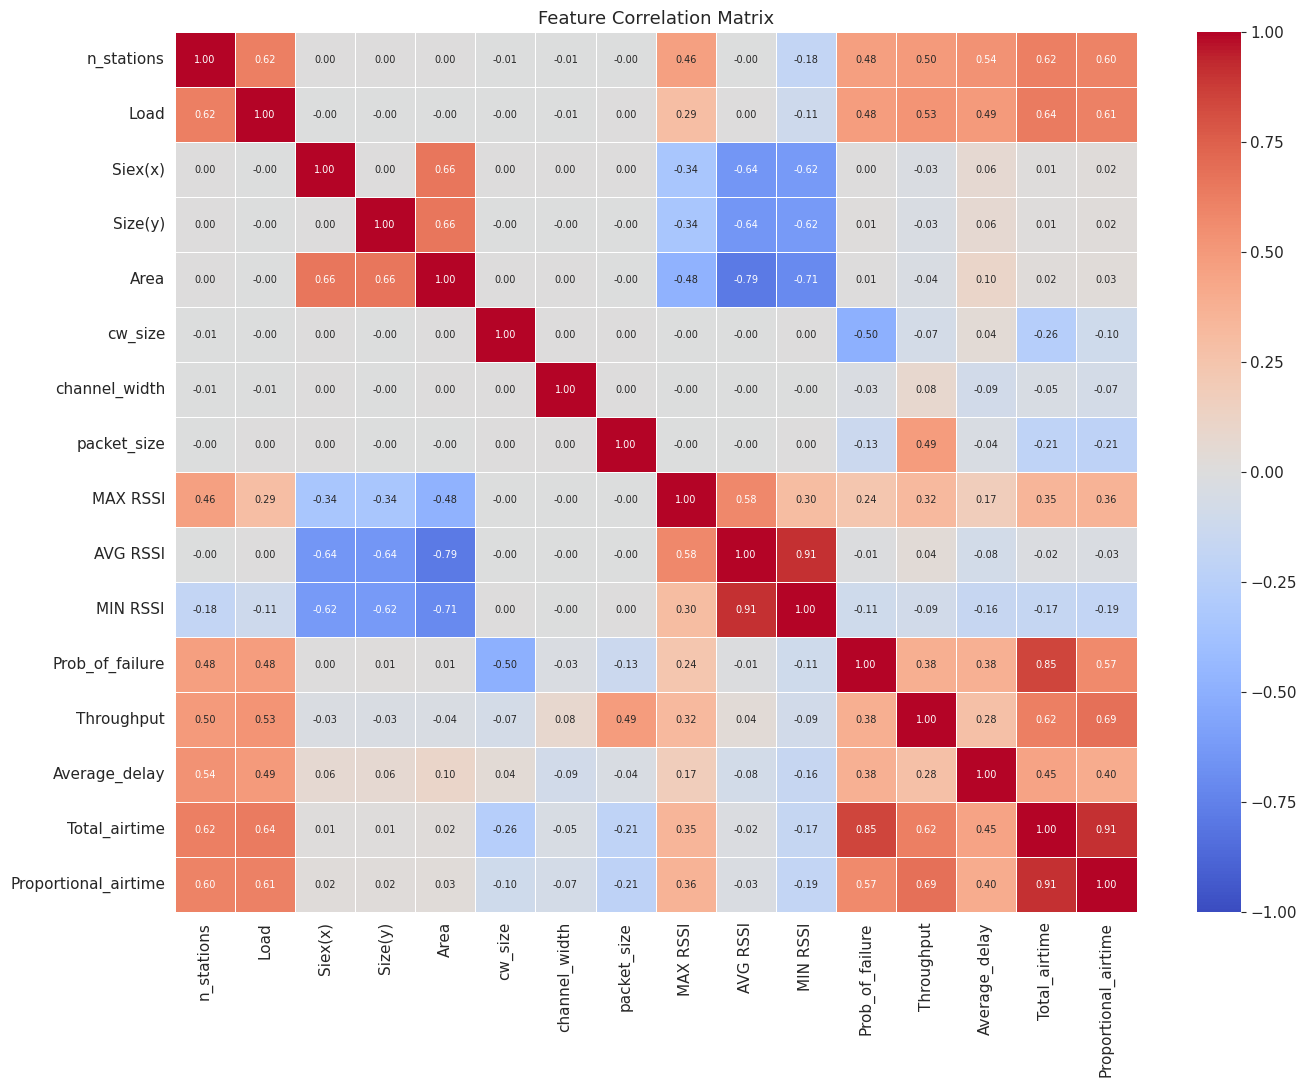

In [ ]:
plt.figure(figsize=(14, 11))
corr = df.corr()
# mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, annot_kws={'size': 7}, vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

Our task consists of predicting several label values (regression) from features. These are the following:
- Probability of failure 
- Throughput
- Average delay 
- Total airtime 
- Proportional airtime 

Now from the correlation matrix we can see some interesting things:
- Number of stations and load => strong correlation with all target labels 
- packet size => strong correlation with throughput 
- Max RSSI => quite strong correlation will all target labels 

### 1.4 Data preprocessing

In [15]:
# ── Define target labels and separate features / targets ──────────────────────
TARGETS = [
    'Prob_of_failure',
    'Throughput',
    'Average_delay',
    'Total_airtime',
    'Proportional_airtime',
]

FEATURE_COLS = [c for c in df.columns if c not in TARGETS]

X = df[FEATURE_COLS].values.astype(np.float64)   # shape: (n_samples, n_features)
y = df[TARGETS].values.astype(np.float64)         # shape: (n_samples, 5)

print(f'Features : {X.shape}')
print(f'Labels   : {y.shape}')
print(f'\nFeature columns : {FEATURE_COLS}')
print(f'Target  columns : {TARGETS}')

Features : (100000, 11)
Labels   : (100000, 5)

Feature columns : ['n_stations', 'Load', 'Siex(x)', 'Size(y)', 'Area', 'cw_size', 'channel_width', 'packet_size', 'MAX RSSI', 'AVG RSSI', 'MIN RSSI']
Target  columns : ['Prob_of_failure', 'Throughput', 'Average_delay', 'Total_airtime', 'Proportional_airtime']


In [16]:
# We clip rather than remove rows to preserve label alignment across 5 targets.
# A 3×IQR fence is conservative enough to keep genuine extreme-but-valid samples.

Q1  = np.percentile(X, 25, axis=0)
Q3  = np.percentile(X, 75, axis=0)
IQR = Q3 - Q1

lower_fence = Q1 - 3.0 * IQR
upper_fence  = Q3 + 3.0 * IQR

outlier_counts = ((X < lower_fence) | (X > upper_fence)).sum(axis=0)
print('Values clipped per feature (3×IQR rule):')
for name, cnt in zip(FEATURE_COLS, outlier_counts):
    if cnt > 0:
        print(f'  {name:<25s}: {cnt:,}')

X = np.clip(X, lower_fence, upper_fence)
print(f'\nX shape after clipping: {X.shape}  (unchanged — no rows dropped)')

Values clipped per feature (3×IQR rule):
  cw_size                  : 11,259
  MAX RSSI                 : 686

X shape after clipping: (100000, 11)  (unchanged — no rows dropped)


Only two features had values outside the 3×IQR fence: cw_size (11,259 clipped values) and MAX RSSI (686). The large count for cw_size is expected — it takes only a handful of discrete values (31, 63, 127, 255) so its IQR is very narrow, making the fence unusually tight. No rows were removed, only clipped, so the X↔y alignment across all 5 labels is fully preserved.

Why do we clip ? 
Clipping makes sense when: the value is real but extreme, it genuinely occurred, just at the tail of the distribution You want to reduce its influence without pretending it was an average observation. 

Mean replacement makes sense when: the outlier is a missing/corrupt value that you need to fill in (e.g., a sensor dropout recorded as 9999). The feature is known to be normally distributed and the value is physically impossible


In [17]:
# Denoising
print('Denoising: handled via 3×IQR clipping (cell above) and z-score standardisation (cell below).')

Denoising: handled via 3×IQR clipping (cell above) and z-score standardisation (cell below).


In [18]:
# Normalization of features/labels 
print('Standardisation will be applied in section 1.5 after the train/test split.')

Standardisation will be applied in section 1.5 after the train/test split.


In [19]:
# ── Alignment check — every feature row has exactly one label row ─────────────
assert X.shape[0] == y.shape[0], "Mismatch: X and y have different number of samples!"
assert y.shape[1] == len(TARGETS),  "Mismatch: y column count does not match TARGETS list!"
assert not np.isnan(X).any(), "NaNs detected in X after clipping!"
assert not np.isnan(y).any(), "NaNs detected in y!"

print(f'Alignment OK — X: {X.shape}, y: {y.shape}')
print(f'No NaN values in X or y.')

Alignment OK — X: (100000, 11), y: (100000, 5)
No NaN values in X or y.


### 1.5 Train / test split (80 % / 20 %)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Training set   : {X_train.shape[0]:,} samples ({100*(1-TEST_SIZE):.0f}%)')
print(f'Test set       : {X_test.shape[0]:,} samples ({100*TEST_SIZE:.0f}%)')

Training set   : 80,000 samples (80%)
Test set       : 20,000 samples (20%)


In [ ]:
# Standardisation, Z-score
x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s  = x_scaler.transform(X_test)

# Scale y too — the 5 labels differ by ~7 orders of magnitude
y_scaler  = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train)
y_test_s  = y_scaler.transform(y_test)

print('Standardisation complete.')
print(f'X_train_s : {X_train_s.shape}  mean≈0, std≈1')
print(f'y_train_s : {y_train_s.shape}  mean≈0, std≈1')
print(f'\ny_train_s means : {y_train_s.mean(axis=0).round(4)}')
print(f'y_train_s stds  : {y_train_s.std(axis=0).round(4)}')

---
## Part II — Model Implementation & Evaluation

A linear regression model can predict multiple labels simultaneously, this is called multi-output linear regression. Instead of learning a single weight vector for one output, the model learns a weight matrix where each column corresponds to one label, so all five targets (Prob of error, Throughput, Average Delay, Total Airtime, Proportional Airtime) are predicted in a single forward pass. The least squares cost function generalizes naturally by summing the MSE across all outputs. In practice, sklearn's LinearRegression supports this out of the box by simply passing a 2D target matrix y with shape (n_samples, 5), and the manual gradient descent implementation requires only a minor change, replacing the weight vector with a weight matrix, while the update rule stays identical.

### 2.1 Manual multi-variable linear regression (Gradient Descent)

In [23]:
class MvLinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=500):
        self.lr          = learning_rate
        self.n_iters     = n_iterations
        self.weights_    = None   # shape: (n_features, n_outputs) matrix with one column per label and number of rows equal to number of features
        self.bias_       = None   # shape: (n_outputs,)
        self.train_loss_ = []     # mean MSE across all labels per iteration
        self.val_loss_   = []
        self.train_loss_per_label_ = []   # (n_iters, n_outputs)
        self.val_loss_per_label_   = []

    # Predicts all 5 labels simultaneously using matrix multiplication with weight matrix W and bias vector b.
    def predict(self, X):
        return X @ self.weights_ + self.bias_   # (n_samples, n_outputs)

    # MSE
    @staticmethod
    def mse(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    # Backpropagation with batch gradient descent to update weights and biases.
    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        n_outputs = y.shape[1]

        # Initialise weight matrix and bias vector at zero
        self.weights_ = np.zeros((n_features, n_outputs))
        self.bias_    = np.zeros(n_outputs)
        self.train_loss_, self.val_loss_ = [], []
        self.train_loss_per_label_, self.val_loss_per_label_ = [], []

        for iteration in range(self.n_iters):
            y_pred = self.predict(X)
            error  = y_pred - y                          # (n_samples, n_outputs)

            # Gradients of MSE w.r.t. W and b
            dW = (2 / n_samples) * (X.T @ error)        # (n_features, n_outputs)
            db = (2 / n_samples) * error.sum(axis=0)    # (n_outputs,)

            self.weights_ -= self.lr * dW
            self.bias_    -= self.lr * db

            # Track losses
            train_per_label = np.mean((y - self.predict(X)) ** 2, axis=0)
            self.train_loss_.append(train_per_label.mean())
            self.train_loss_per_label_.append(train_per_label)

            if X_val is not None:
                val_per_label = np.mean((y_val - self.predict(X_val)) ** 2, axis=0)
                self.val_loss_.append(val_per_label.mean())
                self.val_loss_per_label_.append(val_per_label)

            if (iteration + 1) % 100 == 0:
                val_str = f'  |  Val MSE = {self.val_loss_[-1]:.6f}' if X_val is not None else ''
                print(f'  Iter {iteration+1:>4d}/{self.n_iters}  |  Train MSE = {self.train_loss_[-1]:.6f}{val_str}')

        return self

### 2.2 Train the model

In [26]:
# ── Train manual GD model (pass test set as validation to track val loss) ─────
print('=== Training MvLinearRegressionGD ===')
gd_model = MvLinearRegressionGD(learning_rate=0.05, n_iterations=500)
gd_model.fit(X_train_s, y_train_s, X_val=X_test_s, y_val=y_test_s)

print(f'\nFinal train MSE : {gd_model.train_loss_[-1]:.6f}')
print(f'Final val   MSE : {gd_model.val_loss_[-1]:.6f}')


=== Training MvLinearRegressionGD ===
  Iter  100/500  |  Train MSE = 0.469464  |  Val MSE = 0.435330
  Iter  200/500  |  Train MSE = 0.468184  |  Val MSE = 0.434107
  Iter  300/500  |  Train MSE = 0.467336  |  Val MSE = 0.433310
  Iter  400/500  |  Train MSE = 0.466769  |  Val MSE = 0.432786
  Iter  500/500  |  Train MSE = 0.466389  |  Val MSE = 0.432442

Final train MSE : 0.466389
Final val   MSE : 0.432442


### 2.3 Model evaluation

In [40]:
y_pred = gd_model.predict(X_test_s)

# For each label and each model, compute MSE on the test set.
rows = []
for i, label in enumerate(TARGETS):
    for model_name, y_pred in [('MvLR', y_pred)]:
        mse  = mean_squared_error(y_test_s[:, i], y_pred[:, i])
        rows.append(dict(Label=label, Model=model_name, MSE=mse))

metrics_df = pd.DataFrame(rows)

print('=== Per-label test-set metrics ===')
display(metrics_df.set_index(['Label', 'Model']).style.format('{:.4f}'))

# Average MSE across all 5 labels for each model
for model_name, y_pred in [('MvLR', y_pred)]:
    mse_vals = [mean_squared_error(y_test_s[:, i], y_pred[:, i]) for i in range(len(TARGETS))]
    print(f'\n{model_name}: mean MSE across labels: {np.mean(mse_vals):.4f}')

=== Per-label test-set metrics ===


,,MSE
Label,Model,
Prob_of_failure,MvLR,0.4463
Throughput,MvLR,0.4091
Average_delay,MvLR,0.4741
Total_airtime,MvLR,0.3792
Proportional_airtime,MvLR,0.4535



MvLR: mean MSE across labels: 0.4324


### 2.4 Plot Training vs Validation loss (average regression from all labels)

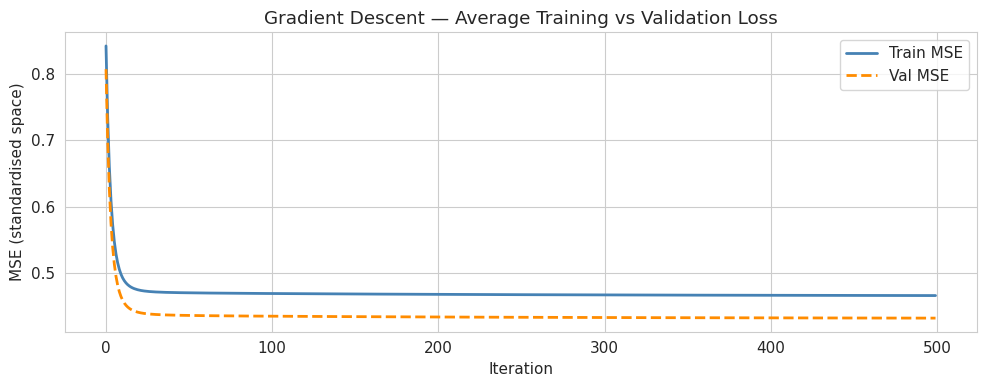

In [34]:
# Average training and validation loss across all labels per iteration
plt.figure(figsize=(10, 4))
plt.plot(gd_model.train_loss_, color='steelblue', linewidth=2, label='Train MSE')
plt.plot(gd_model.val_loss_,   color='darkorange', linewidth=2, label='Val MSE', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('MSE (standardised space)')
plt.title('Gradient Descent — Average Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

We can see a very nice loss evolution of the model, where Training and Validation follow similar curves. Very rapid decrease in loss, and then a plateauing. In fact, its quite clear that the model does not improve much after relatively few steps. As such, the training could have finished already at 50 steps. 

However, one unexpected thing we see is that validation is lower than training. The only logical explanation for this is that the random 80/20 split happened to place slightly less variable, easier-to-predict samples in the test set. Since linear regression cannot overfit in the classical sense (no iterative tuning on validation data), a lower validation loss simply means the test samples happen to lie closer to the fitted hyperplane.

### 2.4 Plot Training vs Validation loss (per label)

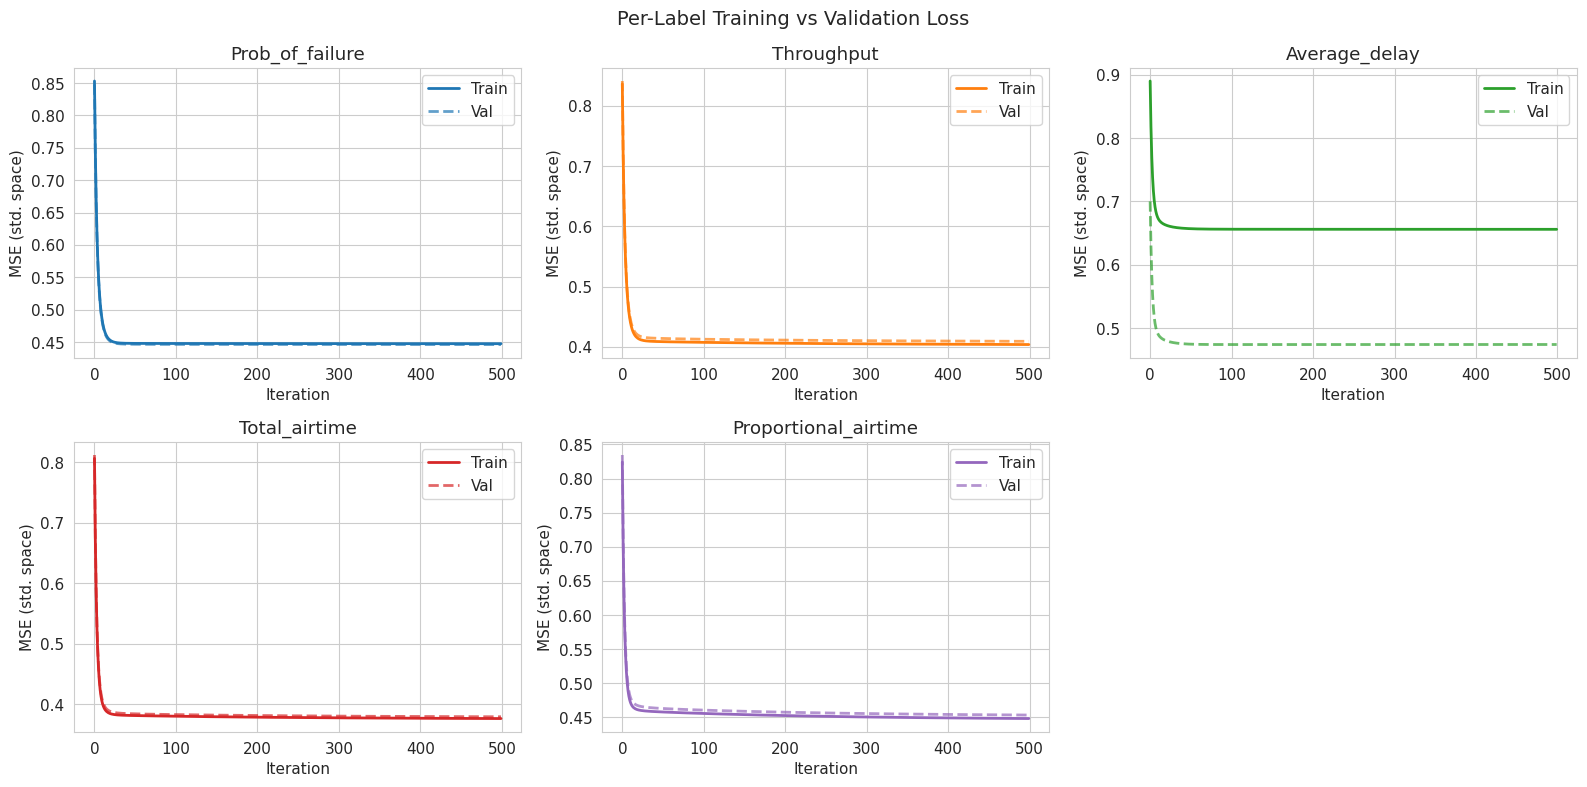

In [31]:
# Per-label training and validation loss curves
train_per_label = np.array(gd_model.train_loss_per_label_)   # (n_iters, 5)
val_per_label   = np.array(gd_model.val_loss_per_label_)

colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, label in enumerate(TARGETS):
    axes[i].plot(train_per_label[:, i], color=colors[i], linewidth=2, label='Train')
    axes[i].plot(val_per_label[:, i],   color=colors[i], linewidth=2, label='Val', linestyle='--', alpha=0.7)
    axes[i].set_title(label)
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('MSE (std. space)')
    axes[i].legend()

axes[-1].set_visible(False)
plt.suptitle('Per-Label Training vs Validation Loss', fontsize=14)
plt.tight_layout()
plt.show()

We can see clear plots for all target labels with graph evolution similar to that of the average, with one outlier in "Avg Delay". Here the training loss is substantially higher than validation loss, this explains the before mentioned observation from average loss, and suggests that Average_delay is the hardest label for the model — likely because its distribution is strongly bimodal (from the histogram: many values near zero, many near 10⁷). And the random split concentrated the harder, high-variance delay samples in the training set. It also suggests that a non-linear model would improve performance specifically on this label.